<a href="https://colab.research.google.com/github/Linzhangcmingdan/vae_toy_case_moon/blob/main/Toycase__VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [4]:
from google.colab import drive
import os
gdrive_path ='/content/gdrive/MyDrive/tu-delft'

#This will mount your google drive under "Mydrive"
drive.mount('/content/gdrive', force_remount=True)
#In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

Mounted at /content/gdrive
['Medium_Understanding_Variational_Autoencoders (VAEs).ipynb']


In [7]:
print("当前工作状态", os.getcwd())

当前工作状态 /content/gdrive/MyDrive/tu-delft


# try toy case

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler




## 1.生成 toycase数据

In [10]:
X, _ = make_moons(n_samples=1000, noise=0.1, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = torch.tensor(X, dtype=torch.float32)

# 2.定义 VAE 结构

In [13]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2_mu = nn.Linear(16, latent_dim)
        self.fc2_logvar = nn.Linear(16, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 16)
        self.fc4 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3.训练 VAE

# 4. VAE 总损失

### 最终的 VAE 损失函数：
$$
\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \mathcal{L}_{\text{KL}}
$$

即：
$$
\mathcal{L} = \sum_{i} (x_i - \hat{x}_i)^2 - \frac{1}{2} \sum_{i} (1 + \log\sigma^2 - \mu^2 - \sigma^2)
$$


In [15]:
input_dim = 2
latent_dim = 2
vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    recon_x, mu, logvar = vae(X)
    loss = loss_function(recon_x, X, mu, logvar)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}:.4f")

Epoch 0, Loss: 2608.738525390625:.4f
Epoch 100, Loss: 2238.722412109375:.4f
Epoch 200, Loss: 2098.497314453125:.4f
Epoch 300, Loss: 2041.8292236328125:.4f
Epoch 400, Loss: 2024.169921875:.4f
Epoch 500, Loss: 2015.2032470703125:.4f
Epoch 600, Loss: 2002.2496337890625:.4f
Epoch 700, Loss: 2005.33642578125:.4f
Epoch 800, Loss: 2000.48828125:.4f
Epoch 900, Loss: 2005.0574951171875:.4f


# 补充说明 VAE 的目标

VAE 训练的目标是**最大化变分下界（ELBO，Evidence Lower Bound）**，等价于**最小化损失**：

$$
\mathcal{L} = \mathbb{E}_{q(z|x)} [\log p(x|z)] - D_{KL} (q(z|x) || p(z))
$$

其中：
- **第一项**：重构损失，衡量 $x$ 与 **VAE** 生成的 $x'$ 之间的误差。
- **第二项**：KL 散度，衡量 $q(z|x)$ 和 $p(z)$（标准正态分布）的差异。

由于我们是**最小化损失**，所以**负的 ELBO 就是 VAE 的损失函数**：

$$
\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \mathcal{L}_{\text{KL}}
$$


# 4.生成新数据

In [16]:
with torch.no_grad():
  z = torch.randn(1000, latent_dim)
  generated_data = vae.decode(z).numpy()
  generated_data = scaler.inverse_transform(generated_data)

# 5.可视化结果

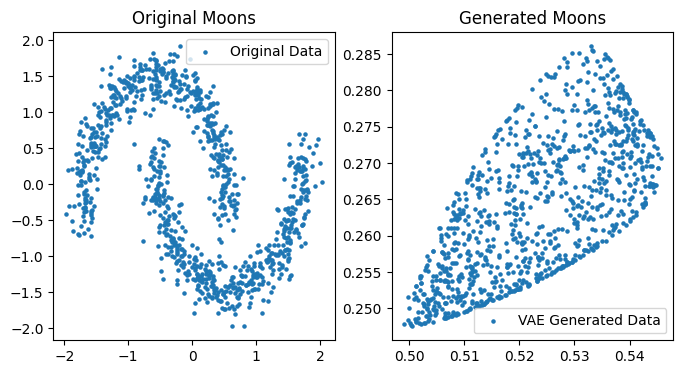

In [17]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:, 1], s=5, label='Original Data')
plt.legend()
plt.title('Original Moons')

plt.subplot(1, 2, 2)
plt.scatter(generated_data[:, 0], generated_data[:, 1], s=5, label='VAE Generated Data')
plt.legend()
plt.title('Generated Moons')

plt.show()
